# 10 — Design Catalog & Multi-Criteria Comparison

Explore the trade-off space between aerodynamic performance and manufacturability:

1. **Build catalog** — baseline, v2 optimized, and alpha-blended designs
2. **Aero evaluation** — 10-target surrogate (with CG correction + control derivatives)
3. **Manufacturability scoring** — curvature, thickness, mold complexity
4. **Pareto analysis** — L/D vs. manufacturability trade-off front
5. **Geometric comparison** — planform overlays, radar charts
6. **STEP export** — batch export for downstream structural/manufacturing pipeline

In [1]:
import sys
sys.path.insert(0, '..')

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from src.optimization.catalog import DesignCatalog
from src.evaluation.manufacturability import compute_manufacturability
from src.visualization.comparison import (
    plot_pareto, plot_radar, plot_planform_overlay, plot_summary_table,
)

## 1. Build the Design Catalog

Two reference points + 4 interpolated designs spanning the full trade-off spectrum.

In [2]:
catalog = DesignCatalog()

# Reference designs
catalog.add_baseline()

# Load v2 optimized design (real CG + elevon trim)
try:
    catalog.add_optimized('../output/best_x_v2.npy')
    print('Using v2 optimized design')
except FileNotFoundError:
    catalog.add_optimized('../output/best_x.npy')
    print('Using v1 design (fallback)')

# alpha-blends: slide continuously between baseline and optimized
catalog.interpolate('baseline', 'optimized', [0.2, 0.4, 0.6, 0.8])

print(f'Catalog: {len(catalog)} designs')
for e in catalog:
    p = e.params
    print(f'  {e.name:15s}  span={2*p.half_span:.2f}m  t/c={p.body_tc_root:.3f}  '
          f'taper={p.taper_ratio:.3f}  sweep={p.le_sweep_deg:.1f}')

Using v2 optimized design
Catalog: 6 designs
  baseline         span=1.50m  t/c=0.180  taper=0.150  sweep=26.0
  optimized        span=1.51m  t/c=0.215  taper=0.290  sweep=33.2
  blend_20         span=1.50m  t/c=0.187  taper=0.178  sweep=27.4
  blend_40         span=1.50m  t/c=0.194  taper=0.206  sweep=28.9
  blend_60         span=1.50m  t/c=0.201  taper=0.234  sweep=30.3
  blend_80         span=1.51m  t/c=0.208  taper=0.262  sweep=31.7


## 2. Aerodynamic Evaluation (Surrogate)

Instant evaluation via the pre-trained MLP ensemble (7 VLM primitives → full reconstruction).

In [3]:
catalog.evaluate_aero(use_surrogate=True, surrogate_path='../models/surrogate_v2_ctrl')

  baseline              L/D=  9.88  X
  optimized             L/D= 10.81  OK
  blend_20              L/D=  9.98  X
  blend_40              L/D= 10.12  X
  blend_60              L/D= 10.30  X
  blend_80              L/D= 10.48  X


## 3. Manufacturability Scoring

Geometric metrics quantifying fabrication difficulty: twist/dihedral gradients, minimum thickness, mold complexity, taper severity.

In [4]:
catalog.evaluate_manufacturability()

# Detailed breakdown for baseline vs optimized
for name in ['baseline', 'optimized']:
    e = catalog[name]
    mm = e.manufacturing_metrics
    print(f'\n=== {name.upper()} (score={mm["manufacturability_score"]:.3f}) ===')
    for k, v in mm.items():
        if k.startswith('sub_'):
            print(f'  {k[4:]:25s}  {v:.3f}')
    print(f'  {"twist_gradient_max":25s}  {mm["twist_gradient_max"]:.1f} °/m')
    print(f'  {"dihedral_gradient_max":25s}  {mm["dihedral_gradient_max"]:.1f} °/m')
    print(f'  {"thickness_tip_mm":25s}  {mm["thickness_tip_mm"]:.1f} mm')
    print(f'  {"n_dihedral_breaks":25s}  {mm["n_dihedral_breaks"]}')

  baseline              manuf=0.631
  optimized             manuf=0.475
  blend_20              manuf=0.653
  blend_40              manuf=0.621
  blend_60              manuf=0.513
  blend_80              manuf=0.496

=== BASELINE (score=0.631) ===
  twist_smoothness           0.593
  dihedral_smoothness        0.159
  dihedral_simplicity        0.667
  tip_robustness             0.912
  taper_simplicity           0.412
  blend_smoothness           0.857
  sweep_continuity           0.778
  twist_simplicity           0.900
  equipment_space            0.169
  mold_size                  1.000
  twist_gradient_max         11.1 °/m
  dihedral_gradient_max      88.9 °/m
  thickness_tip_mm           7.6 mm
  n_dihedral_breaks          1

=== OPTIMIZED (score=0.475) ===
  twist_smoothness           0.000
  dihedral_smoothness        0.000
  dihedral_simplicity        0.333
  tip_robustness             1.000
  taper_simplicity           1.000
  blend_smoothness           0.500
  sweep_continui

## 4. Summary Table

In [5]:
from src.geometry.control_surfaces import compute_control_surface_geometry

print(catalog.summary())
print()

# Pandas DataFrame for detailed comparison
df = catalog.to_dataframe()

# Add control surface dimension columns
elevon_spans = []
aileron_spans = []
for e in catalog:
    cs_list = compute_control_surface_geometry(e.params)
    ev_span = 0.0
    ai_span = 0.0
    for cs in cs_list:
        if 'elevon' in cs.name.lower():
            ev_span = cs.span * 100  # m -> cm
        elif 'aileron' in cs.name.lower():
            ai_span = cs.span * 100  # m -> cm
    elevon_spans.append(ev_span)
    aileron_spans.append(ai_span)

df['elevon_span_cm'] = elevon_spans
df['aileron_span_cm'] = aileron_spans

cols = ['origin', 'L_over_D', 'static_margin', 'is_feasible',
        'manuf_manufacturability_score', 'struct_mass', 'endurance_min',
        'half_span', 'body_tc_root', 'taper_ratio',
        'elevon_deflection', 'Cl_beta', 'x_cg_frac',
        'elevon_span_cm', 'aileron_span_cm']
display(df[[c for c in cols if c in df.columns]].round(3))

DesignCatalog: 6 designs

Name                 Origin            L/D  Feas  Manuf Tags
------------------------------------------------------------
baseline             default          9.88     X  0.631 baseline, reference
optimized            optimization    10.81    OK  0.475 optimized, reference, feasible
blend_20             interpolation    9.98     X  0.653 blend, alpha=0.20
blend_40             interpolation   10.12     X  0.621 blend, alpha=0.40
blend_60             interpolation   10.30     X  0.513 blend, alpha=0.60
blend_80             interpolation   10.48     X  0.496 blend, alpha=0.80



,origin,L_over_D,static_margin,is_feasible,manuf_manufacturability_score,struct_mass,endurance_min,half_span,body_tc_root,taper_ratio,elevon_deflection,Cl_beta,elevon_span_cm,aileron_span_cm
name,,,,,,,,,,,,,,
baseline,default,9.883,0.028,False,0.631,0.706,11.756,0.750,0.180,0.150,-25.000,-0.035,35.036,24.533
optimized,optimization,10.811,0.058,True,0.475,0.793,12.859,0.754,0.215,0.290,6.949,-0.014,40.257,28.182
blend_20,interpolation,9.978,0.037,False,0.653,0.724,11.869,0.751,0.187,0.178,-25.000,-0.038,35.978,25.191
blend_40,interpolation,10.123,0.038,False,0.621,0.741,12.041,0.752,0.194,0.206,-25.000,-0.038,36.967,25.882
blend_60,interpolation,10.300,0.037,False,0.513,0.758,12.252,0.752,0.201,0.234,-25.000,-0.033,38.008,26.609
blend_80,interpolation,10.484,0.041,False,0.496,0.775,12.471,0.753,0.208,0.262,-25.000,-0.025,39.103,27.375


## 5. Pareto Plot — L/D vs. Manufacturability

The fundamental trade-off: aerodynamic performance vs. fabrication ease. The Pareto front shows the best achievable compromise at each performance level.

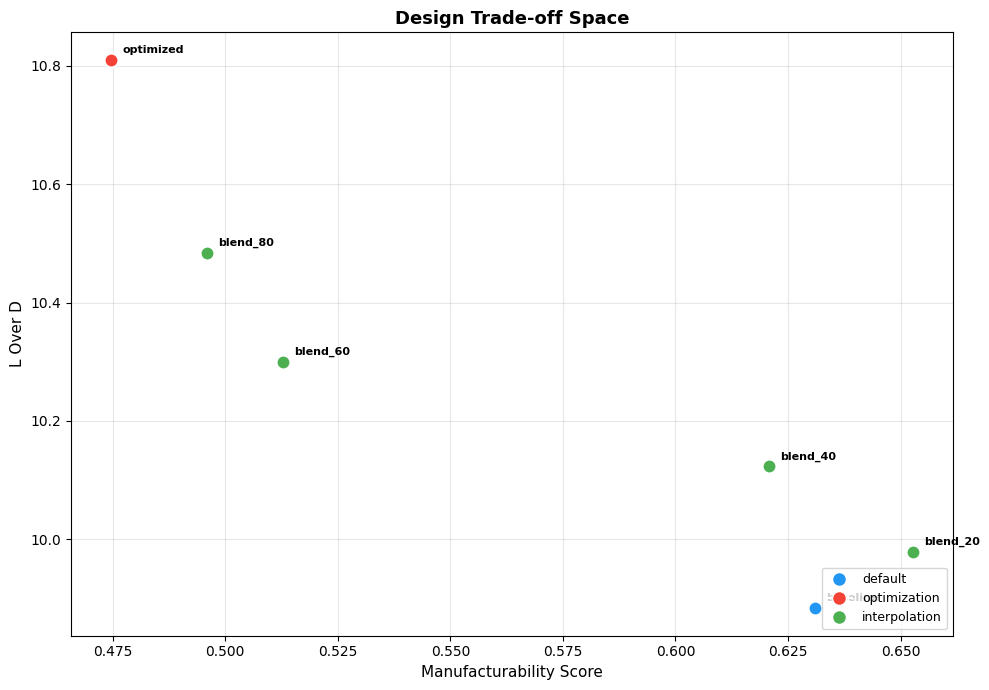

In [6]:
fig = plot_pareto(catalog, save_path='../output/catalog_pareto.png')
plt.show()

## 6. Radar Chart — Multi-Criteria Comparison

Normalized comparison across 6 dimensions: L/D, stability, manufacturability, volume, endurance, and structural mass.

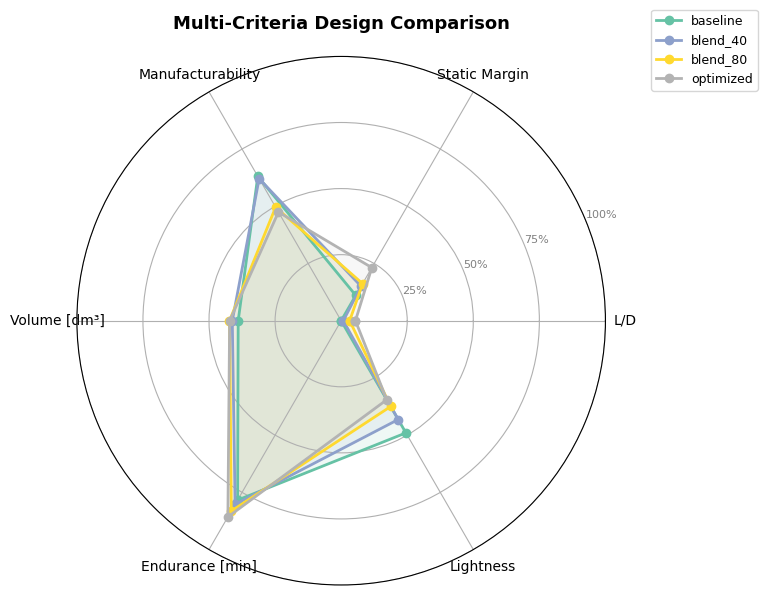

In [7]:
# Compare the two references + the best compromise
fig = plot_radar(catalog, designs=['baseline', 'blend_40', 'blend_80', 'optimized'],
                 save_path='../output/catalog_radar.png')
plt.show()

## 7. Geometric Comparison — Planform Overlays

Top view (planform) and front view (dihedral) superimposed for all catalog designs.

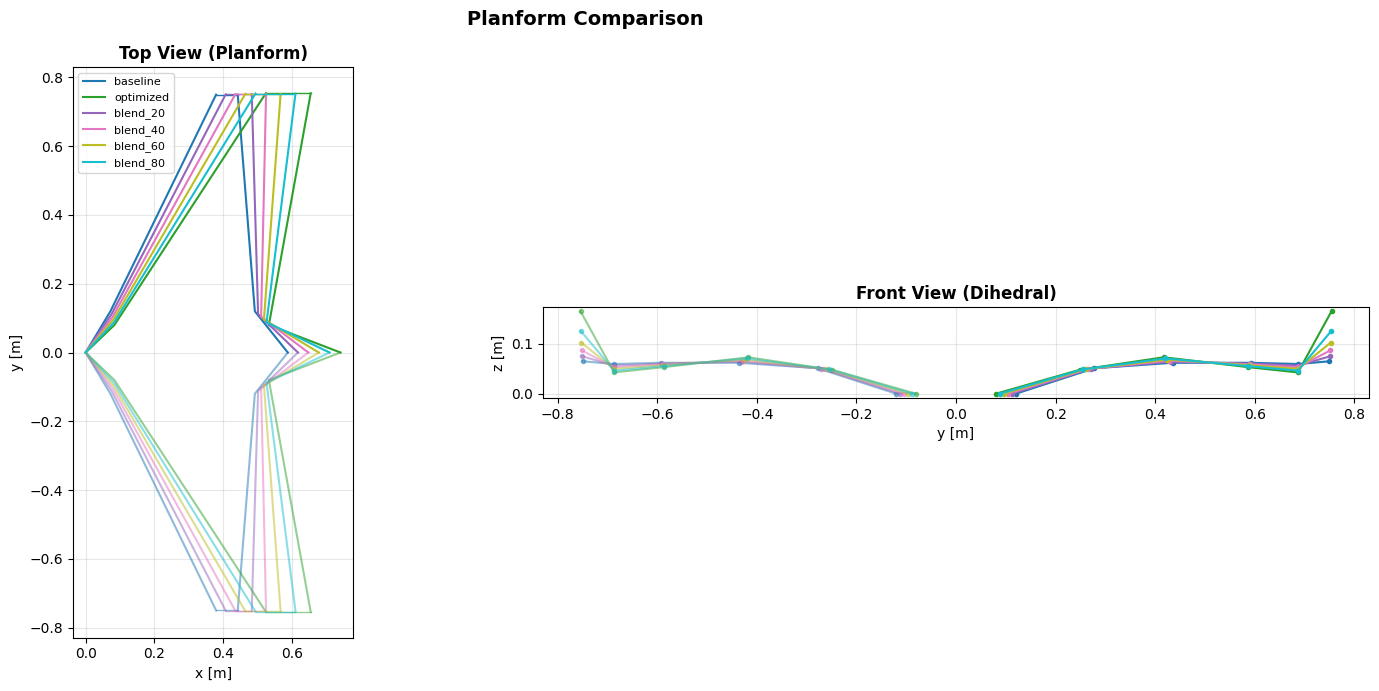

In [8]:
fig = plot_planform_overlay(catalog, save_path='../output/catalog_planforms.png')
plt.show()

## 8. Summary Table (visual)

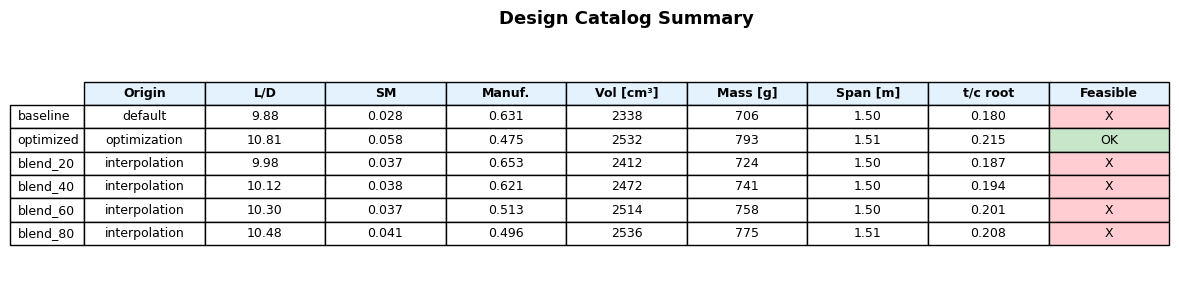

In [9]:
fig = plot_summary_table(catalog, save_path='../output/catalog_table.png')
plt.show()

## 9. Batch STEP Export

Export selected designs as STEP v2 (OML solid) for downstream structural analysis.
Each file is a watertight NURBS solid ready for FEA meshing.

In [10]:
# Select which designs to export (uncomment to run — takes ~30s per design)
# paths = catalog.export_all_step(
#     output_dir='../output/catalog',
#     version='v2',
#     n_profile=100,
# )
# for name, path in paths.items():
#     print(f'  {name}: {path}')

## 10. Save Catalog

Persist the catalog (designs + metrics) as JSON for use by external pipelines (FEA, CFD, manufacturing).

In [11]:
catalog.save('../output/catalog.json')
print(f'Catalog saved: {len(catalog)} designs → output/catalog.json')

# To reload in another session:
# catalog = DesignCatalog.load('../output/catalog.json')

Catalog saved: 6 designs → output/catalog.json
